<a href="https://colab.research.google.com/github/luiseduaardo/ml-ds/blob/main/supervised-learning/regressao_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
import pandas as pd

df = pd.read_csv("../data/housing/housing.csv")
df.sample(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
157,5495000,2817,4,2,2,no,yes,yes,no,no,1,no,furnished
62,7070000,6240,4,2,2,yes,no,no,no,yes,1,no,furnished
199,4907000,4200,3,1,2,yes,no,no,no,no,1,no,furnished
303,4200000,4500,3,1,1,yes,no,yes,no,no,0,no,furnished
71,6755000,6000,4,2,4,yes,no,no,no,yes,0,no,unfurnished
123,5950000,7320,4,2,2,yes,no,no,no,no,0,no,furnished
119,5950000,7020,3,1,1,yes,no,yes,no,yes,2,yes,semi-furnished
395,3500000,3600,6,1,2,yes,no,no,no,no,1,no,unfurnished
290,4200000,2610,4,3,2,no,no,no,no,no,0,no,semi-furnished
507,2590000,3600,2,1,1,yes,no,no,no,no,0,no,unfurnished


### Pré processamento

In [67]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [68]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, dtype=int)
colunas_ohe = ['furnishingstatus']

matriz_ohe = ohe.fit_transform(df[colunas_ohe])
colunas = ohe.get_feature_names_out(colunas_ohe)

df_ohe = pd.DataFrame(matriz_ohe, columns=colunas, index=df.index)

df = pd.concat([df, df_ohe], axis=1).drop(columns=colunas_ohe)

In [69]:
threshold = df['price'].quantile(0.5)
df['target'] = (df['price'] > threshold).astype(int)

In [70]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,target
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0,1


In [71]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["price", "target"])
y = df["target"]

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Inferência

In [73]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [74]:
predictions = model.predict(X_test_scaled)

In [75]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import sqrt

mae = mean_absolute_error(Y_test, predictions)
rmse = sqrt(mean_squared_error(Y_test, predictions))

print(f"Coefciente de determinação (R²): {model.score(X_train, Y_train):.2f}")
print(f"Root-Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

Coefciente de determinação (R²): 0.51
Root-Mean Squared Error: 0.35
Mean Absolute Error: 0.28


### Interpretação dos Coeficientes

Os coeficientes indicam a influência de cada feature na predição:
- **Coeficiente positivo**: Quanto maior o valor da feature, maior a probabilidade de preço alto
- **Coeficiente negativo**: Quanto maior o valor da feature, menor a probabilidade de preço alto
- **Magnitude (valor absoluto)**: Maior magnitude = maior influência na predição

In [76]:
comp = pd.DataFrame({'parametro': df.columns[1:-1], "coefciente": model.coef_})
comp

,parametro,coefciente
0,area,0.156606
1,bedrooms,0.027183
2,bathrooms,0.065833
3,stories,0.084568
4,mainroad,0.045829
5,guestroom,0.051539
6,basement,0.073043
7,hotwaterheating,0.012952
8,airconditioning,0.094962
9,parking,0.006037


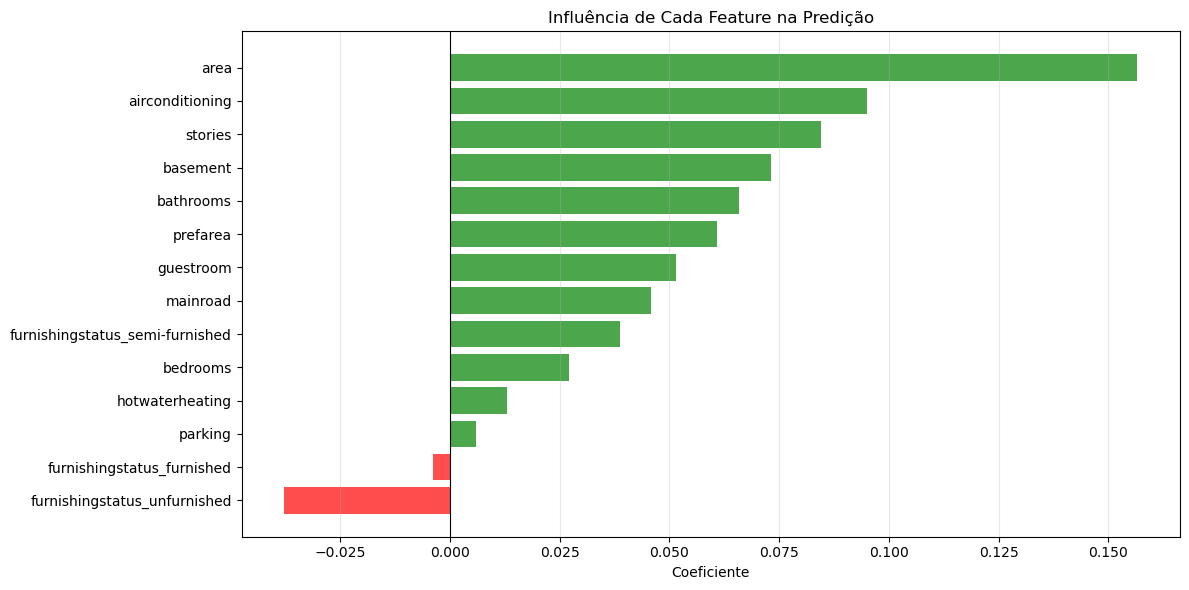

In [77]:
# Visualização dos coeficientes
fig, ax = plt.subplots(1, figsize=(12, 6))

comp_sorted = comp.sort_values('coefciente')

colors = ['red' if x < 0 else 'green' for x in comp_sorted['coefciente']]
ax.barh(comp_sorted['parametro'], comp_sorted['coefciente'], color=colors, alpha=0.7)
ax.set_xlabel('Coeficiente')
ax.set_title('Influência de Cada Feature na Predição')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
